#                                                                  SISTEMA M/M/k

## Rojas Irineo Alejandro 


En este trabajo simulamos una trayectoria de una Cadena de Markov en Tiempo Continuo (CTMC) para el sistema M/M/k, más especificamente con k = 1,5, $\infty$. Para ello realizamos lo siguiente, en una función que creamos: 

1. Inicializar:$$T_0 = 0, \quad Y_0 = x_0$$ con $$x_0 = 0$$
Para $n = 0, 1, 2, \dots$ repetir:
2. Calcular la tasa total de salida del estado actual (la tasa de que ocurra una salida o llegada):$$\lambda(Y_n) = \sum_{j \neq Y_n} q(Y_n, j)$$
3. Generar el tiempo de permanencia: En este caso ocupamos la versión 2: $t_{n+1} \sim \text{Exp}(\lambda(Y_n))$
4. Actualizar el tiempo:$$T_{n+1} = T_n + t_{n+1}$$
5. Elegir el siguiente estado $Y_{n+1}$ con probabilidad:$$P(Y_{n+1} = j \mid Y_n) = \frac{q(Y_n, j)}{\lambda(Y_n)}$$
6. Definir el proceso continuo mediante:$$X(t) = Y_n \quad \text{para} \quad T_n \le t < T_{n+1}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display

# Definimos una función para simular el sistema M/M/k y despues solo sustituir k 
def sistema_MMk (lamda, mu, k, tiempo_final):
# 1.
    tiempo_actual = 0   # Inicializamos el tiempo, con T_0 = 0
    x = 0   # Inicializamos el estado, con Y_0 = 0 

 # Creamos listas para almacenar las trayectorias de la simulación   
    T_n = [tiempo_actual]   # Tiempos
    Y_n = [x]               # Estados del sistema (número de clientes)

# Creamos un bucle para simular el proceso hasta alcanzar el tiempo final
    while tiempo_actual < tiempo_final:
        # Evaluamos la tasa de salida dependiendo del número de clientes en el sistema y el número de servidores disponibles
        if x == 0:
            tasa_salida = 0  # Solo llegadas, pues el sistema está vacío
        elif x < k:
            tasa_salida = x * mu  # Con tasa  mu sale el cliente, pero no se alcanza el máximo de servidores
        else:
            tasa_salida = mu * k  # Llegadas y servicios con k servidores

        tasa_llegada = lamda      # Tasa de llegada constante (lambda)
    
    # 2. 
        tasa_total = tasa_llegada + tasa_salida  # Calculamos la tasa total de eventos (llegada con salida)

    # 3. 
        tiempo_permanencia = np.random.exponential(1 / tasa_total)  # Simulamos el tiempo hasta el próximo evento (llegada o salida)
    
    # 4.
        tiempo_actual += tiempo_permanencia  # Actualizamos el tiempo actual
        T_n.append(tiempo_actual)  # Almacenamos el tiempo del evento que ocurrió
    
    # 5. 
        proba = tasa_llegada / tasa_total  # Calculamos la probabilidad de que el próximo evento sea una llegada
        aleatorio = np.random.uniform(0, 1)  # Generamos un número aleatorio para decidir el tipo de evento (llegada o salida)
        if aleatorio < proba:
            x += 1  # Ocurre una llegada, incrementamos el número de clientes
        else:
            x -= 1  # Ocurre una salida, restamos el número de clientes

    # 6.
        Y_n.append(x)  # Almacenamos el nuevo estado del sistema
    
    # Configuuramos el grafico de la trayectoria que simulamos 
    sns.set_theme(style = "darkgrid")
    plt.figure(figsize = (12, 6))
    sns.lineplot(
        x = T_n, 
        y = Y_n, 
        drawstyle = "steps-post", 
        color = "#06a7b2f8",          
        linewidth = 2.5,             
        marker = "o",                
        markersize = 7,              
        markerfacecolor = "#bb5b45", 
        markeredgecolor = "white",  
        markeredgewidth = 1.5)
    
    plt.title(f"Sistema M/M/{k}", fontsize=15, fontweight = "bold")
    plt.xlabel("Tiempo(T_n)", fontsize=12)
    plt.ylabel("Clientes en el sistema", fontsize=12)
    plt.yticks(range(0, max(Y_n) + 2))
    plt.tight_layout()
    plt.show()

    # Creamos un DataFrame para mostrar los tiempos y estados del sistema
    tiempo_estado = pd.DataFrame({"Tiempo": T_n, "Estado": Y_n}) 
    print(f"Los primeros Tiempos y estados del sistema M/M/{k} son: ") 
    display(tiempo_estado.head(10))        # Mostramos los primeros 10 tiempos y estados del sistema


### Ejemplo de prueba para un sistema M/M/1

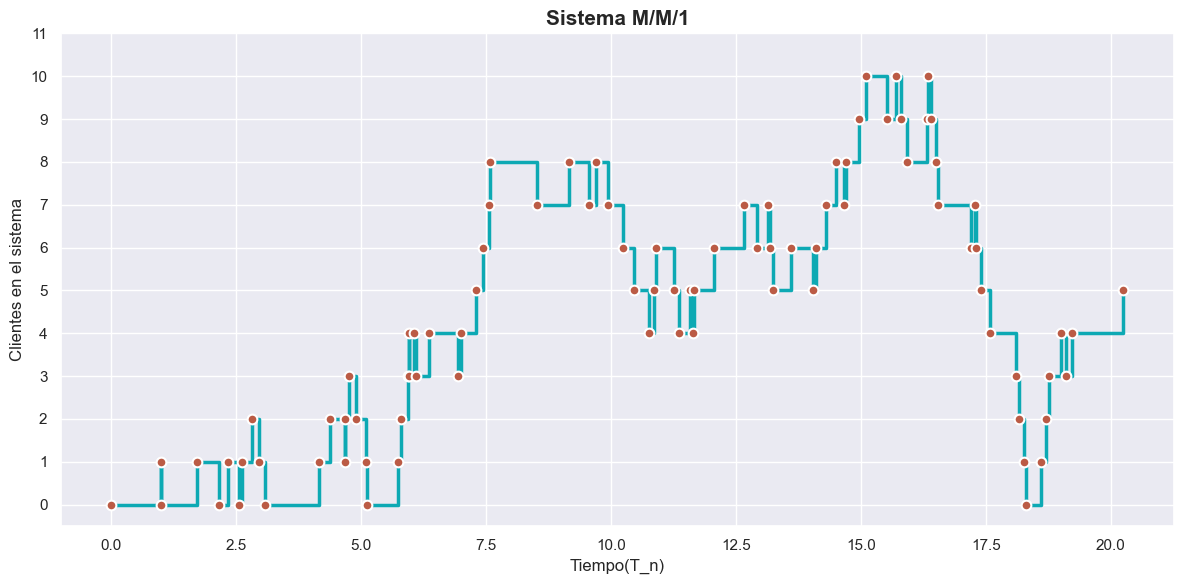

Los primeros Tiempos y estados del sistema M/M/1 son: 


,Tiempo,Estado
0,0.000000,0
1,0.989108,1
2,0.992588,0
3,1.712795,1
4,2.163614,0
5,2.336724,1
6,2.553170,0
7,2.620103,1
8,2.810323,2
9,2.957869,1


In [108]:
# Prueba del sistema M/M/1
sistema_MMk(lamda = 2, mu = 3, k = 1, tiempo_final = 20)

Conclusión de este sistema: 

En esta prueba, aunque el servidor era más rápido, pues la tasa de salida era 3, en comparacón con la tasa de llegada (2), se noto que el sistema todavía es un poco lento para reaccionar. Como $k = 1$, la velocidad máxima para liberar el servidor está topada a 3. Esto provoca que, si tenemos llegadas muy seguido, se empiece a hacer fila o cola como se le llama al sistema. Además, como la tasa total no puede crecer mucho, los tiempos de permanencia (los momentos de pausa entre cada evento) son más largos.

### Ejemplo de prueba para un sistema M/M/5

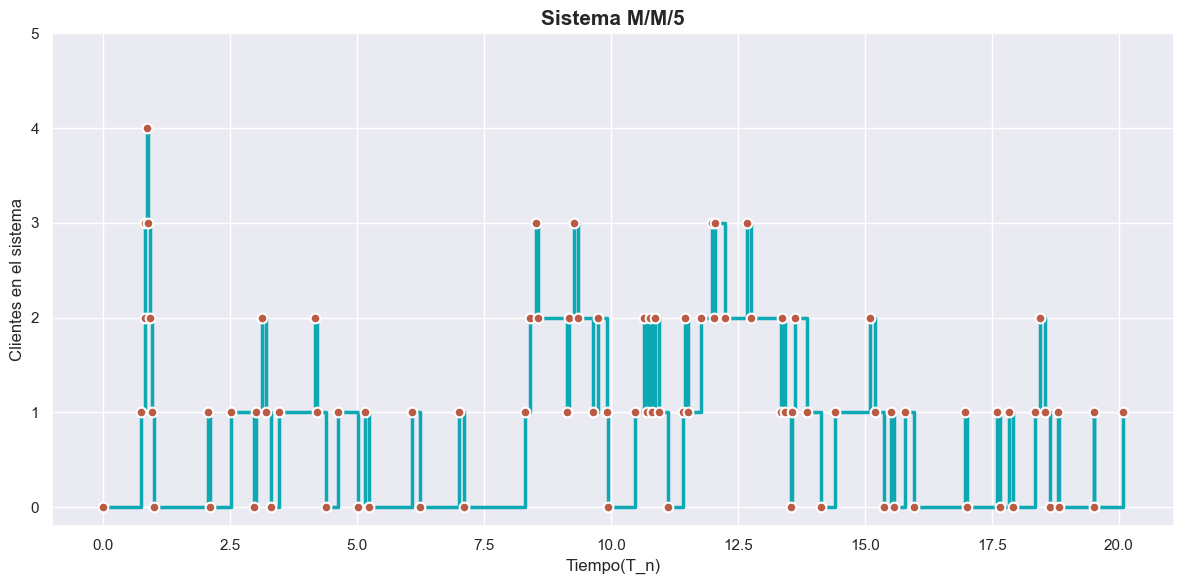

Los primeros Tiempos y estados del sistema M/M/5 son: 


,Tiempo,Estado
0,0.000000,0
1,0.740981,1
2,0.819343,2
3,0.824376,3
4,0.865428,4
5,0.873668,3
6,0.917629,2
7,0.958000,1
8,0.993286,0
9,2.055498,1


In [111]:
# Prueba del sistema M/M/5
sistema_MMk(lamda = 2, mu = 3, k = 5, tiempo_final = 20)


Conclusión de este sistema: 

Al cambiar a $k = 5$ con los mismos valores, la dinámica del sistema cambia por completo. Ahora la capacidad máxima del servidor es 15 (5 cajeros por la tasa de salida = 3). Lo que se observa es que prácticamente es imposible que se forme una fila. En cuanto entran 2 o 3 personas, la tasa de salida se suma, haciendo que el tiempo de permanencia baje bastante. El sistema reacciona mucho más rápido y "saca" cada llegada casi al mismo ritmo que entran.

### Ejemplo de prueba para un sistema M/M/$\infty$

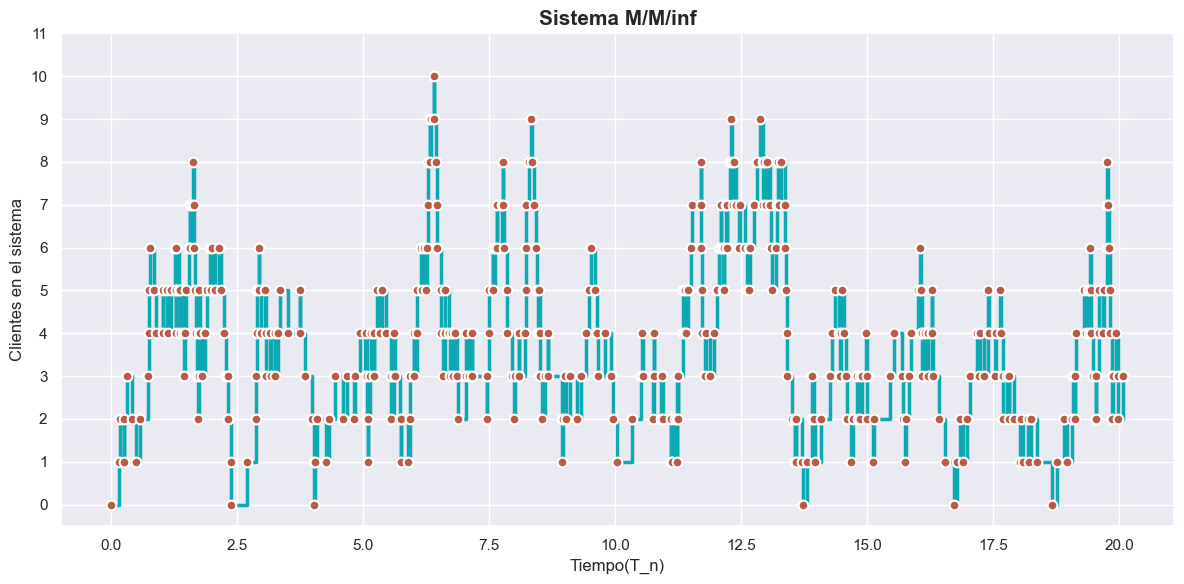

Los primeros Tiempos y estados del sistema M/M/inf son: 


,Tiempo,Estado
0,0.000000,0
1,0.147062,1
2,0.176838,2
3,0.243463,1
4,0.260521,2
5,0.302335,3
6,0.402571,2
7,0.481288,1
8,0.575728,2
9,0.727286,3


In [112]:
# Prueba del sistema M/M/infinito
sistema_MMk(lamda = 10, mu = 3, k = float("inf"), tiempo_final = 20)

Conclusión de este sistema: 

Con estas tres pruebas se puede comprobar cómo afecta el valor de $k$, cosa que en este ultimo sistema no es la excepción. Mientras más servidores añadimos, la tasa total de eventos sube drásticamente. De modo que podemos decir que como el tiempo de permanencia se calcula dividiendo 1 entre esa tasa total, al tener más cajeros trabajando, los tiempos de espera del sistema se hacen más pequeños y las salidas ocurren cada vez más rápido